In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl

In [7]:
def get_csv(model, mode):
    table = pd.read_csv(f'{model}_{mode}.csv')
    cols = [col.split('-')[-1].strip() for col in table.columns]
    table.columns = cols
    index = 'epoch' if mode == 'epoch' else 'wallclock_time'
    table = table[[index, 'loss']]
    return table

csvs = {}
for model in ['tabsmall', 'tabfast', 'tabflex']:
    csvs[model] = {}
    for mode in ['epoch', 'wallclock']:
        csvs[model][mode] = get_csv(model, mode)

In [14]:
mpl.rcParams.update(mpl.rcParamsDefault)
colors = ['#073B4C', '#DD3497', '#06D6A0', '#49006A', '#FFD166','#118AB2', '#AE017E', '#7A0177',]
markers = ['o', '<', 's', 'p', 'P', 'X', 'D', 'd', 'v', 'h', 'H', '8', '>', '*', '1', '2', '3', '4', 'x', '+', '|', '_']
line_styles = ['--', '-', '-.', ':']
mpl.rcParams['patch.linewidth']=0.5 #width of the boundary of legend

In [22]:
legend_converter = {
    'tabsmall': 'TabFlex-S100',
    'tabfast': 'TabFlex-L100',
    'tabflex': 'TabFlex-H1K',
}

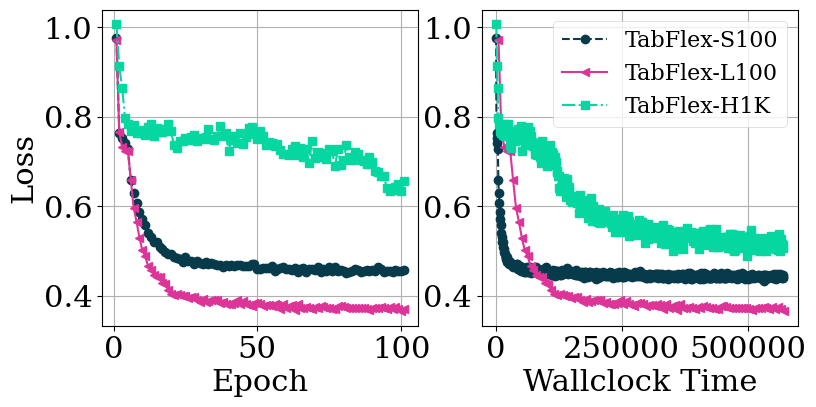

In [49]:
plt.rc('xtick', labelsize=22)
plt.rc('ytick', labelsize=22)
mpl.rcParams['patch.linewidth'] = 0.5
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['DejaVu Serif']  # Change to a different serif font

fig, axs = plt.subplots(1, 2)
fig.subplots_adjust(left=0.12, bottom=.2, right=0.99, top=0.99, wspace=0.2, hspace=0.5)
fig.set_size_inches(8,4)
for i, model in enumerate(['tabsmall', 'tabfast', 'tabflex']):
    data = csvs[model]['epoch'].loc[:100]
    axs[0].plot(
        data['epoch'], 
        data['loss'], 
        marker=markers[i], 
        linestyle=line_styles[i], 
        label=legend_converter[model],
        color=colors[i],
    )
axs[0].grid(True)
axs[0].set_xlabel('Epoch', fontsize=22)
axs[0].set_ylabel('Loss', fontsize=22)

for i, model in enumerate(['tabsmall', 'tabfast', 'tabflex']):
    data = csvs[model]['wallclock']
    data = data[data['wallclock_time'] <= 571407.5625]
    axs[1].plot(
        data['wallclock_time'], 
        data['loss'], 
        marker=markers[i], 
        linestyle=line_styles[i], 
        label=legend_converter[model],
        color=colors[i],
    )

axs[1].legend(fontsize=16)
axs[1].grid(True)
axs[1].set_xlabel('Wallclock Time', fontsize=22)
# axs[1].set_ylabel('Loss', fontsize=22)

plt.savefig('../figures/loss_vis.pdf')
plt.show()